# Implement an Evaluator-Optimizer Workflow With OpenAI Agents SDK and LangGraph

## Overview
So far you have learned about four **agentic design patterns**:

- **Prompt chaining** (deterministic workflows)
- **Routing** (conditional branching)
- **Parallelization** (concurrent execution)
- **Orchestrator workflow** (dynamic task planning)

For all four patterns, workflows executed once and returned a result. But what if that result isn't good enough? What if you need the system to **evaluate its own output** and improve it through iteration?

That’s the  **evaluator-optimizer** agentic design pattern, also known as **plan reflection**. It’s a powerful technique that applies reflection &mdash; one of the most effective prompt engineering techniques &mdash; at the system level, rather than within a single LLM call.

In this activity, you’ll explore the evaluator–optimizer pattern by implementing multiple agentic workflows with evaluation and optimization loops using both the OpenAI Agents SDK and LangGraph.

## Evaluator-Optimizer (Plan Reflection)

**What is the Evaluator-Optimizer Pattern?**

The evaluator-optimizer pattern creates a feedback loop where one LLM generates content and another LLM evaluates it. If the evaluation fails, feedback is provided and the generator tries again. This continues until the output meets quality standards. In practice, the generator LLM can be a smaller model than the evaluator model to reduce costs.

**The Core Loop:**

```
Generate → Evaluate → Pass? → Yes → Done
                         ↓
                        No
                         ↓
               Optimize with Feedback → (back to Evaluate)
```

**Three Types of Reflection:**

1. **Self-reflection**: The same LLM evaluates its own output. Simplest and fastest to deploy. Works surprisingly well for many use cases.

2. **Cross-reflection (evaluator-optimizer)**: A separate LLM evaluates the first LLM's output. This brings several advantages:
   - Mix and match models from different providers
   - Separation of concerns (generator vs. evaluator)
   - The evaluator gets a clean context window
   - You can update the evaluator independently

3. **Human reflection**: A human reviews the output and provides feedback. The agent incorporates this feedback before proceeding.

**When to Use This Pattern:**

This technique is effective when we have clear evaluation criteria, and iterative refinement based on this criteria provides sufficient signal and value to the system to improve its outputs.


For example:

| Scenario | Why Evaluator-Optimizer Helps |
|----------|------------------------------|
| Content must meet specific standards | Evaluator checks compliance |
| Quality varies and needs verification | Iterative improvement until "good enough" |
| Explaining complex concepts simply | Check if explanation is actually simple |
| Creative writing that must be engaging | Evaluate and refine until engaging |
| Code generation | Verify code correctness, refine if bugs found |

**The Key Insight:**

Reflection at the prompt level &mdash; asking an LLM to review its own response  &mdash; is a proven technique, and you have already implemented this earlier. The evaluator-optimizer pattern applies this at the **system level**, with dedicated agents and structured feedback loops.

To efficiently deploy this pattern, we can use the following safeguards:

1. **Maximum iterations**: Always set a limit to prevent infinite loops
2. **Diminishing returns**: After several iterations, accept "good enough" results
3. **Clear criteria**: The evaluator needs specific, measurable standards

**Real-World Examples:**

Some real-world applications where this technique can work well are:

- **Concept explainer**: Generate explanation → Check if a 5-year-old could understand → Refine if too complex
- **Story writing**: Generate outline → Evaluate for engagement → Improve based on feedback
- **Code review**: Generate code → Check for bugs/style → Fix issues found
- **Marketing copy**: Generate description → Check tone/persuasiveness → Refine

Let's see this in action.

### Initial Setup

Let's import some of the necessary libraries.

#### Run the Following Cell

In [1]:
# === Imports and Setup ===
import asyncio
from pydantic import BaseModel, Field
from typing import Literal
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
from agents import Agent, Runner, ModelSettings, set_tracing_disabled
from IPython.display import display, Markdown, Image
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
set_tracing_disabled(True)

# === Initialize LLM ===
llm = ChatOpenAI(model="gpt-4.1")

## Evaluator-Optimizer With OpenAI Agents SDK

### Example: Implement a Concept Explanation Workflow for Children

This workflow demonstrates iterative refinement: explain a complex concept at a level a 5-year-old can understand, then verify and improve until it passes evaluation.

**The scenario:** A user provides a complex concept like: *"Transformers work by converting each word into three vectors (queries, keys, and values), then comparing every word's query against every other word's key to calculate attention scores that determine how much each word should 'focus on' every other word."*

The system must:
1. **Generate** an initial explanation at a 5-year-old's level
2. **Evaluate** whether the explanation is truly understandable by a 5-year-old
3. **Optimize** based on feedback if needed
4. **Repeat** until the evaluator approves or max iterations reached

**The Architecture:**

```
Concept → [Generator] → [Evaluator] ── Pass? ── Yes → Done
                              ↑         │
                              │        No + Feedback
                              │         │
                              │         ↓
                              └── [Optimizer]
```

**Note**: The Generator only runs once. The loop is between Evaluator and Optimizer, and each iteration refines the explanation based on feedback until it passes.

**Why Cross-Reflection (Evaluator-Optimizer)?**

With cross-reflection, we use another LLM to evaluate the output of the first one. This brings several advantages:
- The evaluator isn't biased by having generated the content, so it can objectively assess whether a 5-year-old would understand
- The evaluator gets a clean context window without getting thrown off track by the generator's reasoning

Let's implement this step by step.

### Step 1: Define the Evaluation Schema with Structured Output

The evaluator needs to output **structured feedback** that we can programmatically process. This is critical for the loop to work:

1. **Grade**: Did the output pass or fail? (We need this to decide whether to loop)
2. **Feedback**: If it failed, what specific improvements are needed?

For our concept explainer, we define a single evaluation schema, `EvaluationResult`, which the evaluator returns on every iteration of the loop. Each field in the schema plays a specific role:
- **`grade`**: This field is typed as `Literal["pass", "fail"]` to restrict the evaluator to a clear, machine-readable decision, and its `Field` description explains when to choose each value so the system can decide whether to stop or continue looping. The evaluator returns `"pass"` if the explanation is appropriate for a 5-year-old, `"fail"` otherwise
- **`feedback`**: This field is typed as a plain string to allow flexible, human-readable guidance, and its `Field` description tells the evaluator when feedback is required and how it should be used to improve the next iteration.

With structured output, the evaluation is a clean Python object we can use in our control flow. 

#### Run the Following Cell

In [2]:
# === Evaluation Schema ===
class EvaluationResult(BaseModel):
    """Structured evaluation feedback from the evaluator."""
    grade: Literal["pass", "fail"] = Field(
        description="Whether the explanation passes ('pass') or needs improvement ('fail')"
    )
    feedback: str = Field(
        description="If grade is 'fail', specific feedback on what needs improvement. If 'pass', can be empty or a brief note."
    )

print("EvaluationResult schema defined with grade (pass/fail) and feedback.")
print("The evaluator will output structured feedback we can use in our loop logic.")

EvaluationResult schema defined with grade (pass/fail) and feedback.
The evaluator will output structured feedback we can use in our loop logic.


### Step 2: Define the Agents

We need three agents:

1. **Generator**: Creates the initial explanation of the concept at a 5-year-old level. Note that for this exercise, we use a much smaller model (GPT-4.1-nano), and a relatively high temperature value (1.2) to show how the evaluator and optimizer carry out their tasks.

2. **Evaluator**: Assesses whether the explanation is truly understandable by a 5-year-old. Uses `output_type=EvaluationResult` for structured feedback.

3. **Optimizer**: Takes the current explanation and the evaluator's feedback, then creates an improved version.

**Why Separate Generator and Optimizer?**

The generator creates from scratch. The optimizer refines based on feedback. While you could use one agent for both, separating them:
- Keeps instructions focused
- Allows different system prompts for each task
- Makes the system easier to debug and tune

#### Run the Following Cell

In [3]:
# === Generator Agent ===
generator_agent = Agent(
    name="Concept Explainer",
    instructions="""You are an expert at translating concepts from an undergraduate 
    level to one that a five-year old can understand.

Use simple language and examples a young child can understand.

Output ONLY the explanation, nothing else.""",
    model="gpt-4.1-nano",
    model_settings=ModelSettings(temperature=1.2)
)

# === Evaluator Agent ===
evaluator_agent = Agent(
    name="Explanation Evaluator",
    instructions="""You are an expert at evaluating whether explanations 
    are appropriate for a five-year-old.

When evaluating an explanation, check:
1. Are the words simple enough for a five year old to understand? (No technical jargon, complex terms)
2. Are the sentences short and clear?
3. Are analogies relatable to a five year old's experience?
4. Would a 5-year-old find this engaging?
5. Are there any grammatical issues?

If the explanation is well-suited for a 5-year-old, grade it as "pass".
If it needs improvement, grade it as "fail" and provide specific, actionable feedback.

Be constructive but strict - a 5-year-old really should be able to understand it.""",
    model="gpt-4.1",
    output_type=EvaluationResult
)

# === Optimizer Agent ===
optimizer_agent = Agent(
    name="Explanation Optimizer",
    instructions="""You are an expert at improving explanations based on feedback.

You will receive:
- The current explanation
- Specific feedback on what needs improvement

Your job is to create an improved version that addresses the feedback.
Keep what's working well and fix what was flagged.

Output ONLY the new, improved explanation, nothing else.""",
    model="gpt-4.1"
)

print("All agents defined: Concept Explainer, Explanation Evaluator, Explanation Optimizer")

All agents defined: Concept Explainer, Explanation Evaluator, Explanation Optimizer


### Step 3: Build the Evaluator-Optimizer Loop

The loop has a clear structure:

1. **Generate** initial explanation
2. **Loop** (with max iterations):
   - Evaluate current explanation
   - If passed, break and return
   - If failed, optimize with feedback and continue

**Important Safeguards:**

```python
max_iterations = 5  # Prevent infinite loops
```

Without a max iteration check, a strict evaluator could create an infinite loop. The evaluator should also be designed to accept adequate (not perfect) results after several iterations.

**The Key Code Pattern:**

```python
for iteration in range(max_iterations):
    # Evaluate
    evaluation = await Runner.run(evaluator_agent, current_explanation)
    
    if evaluation.final_output.grade == "pass":
        return current_explanation  # Success!
    
    # Optimize with feedback
    improved = await Runner.run(
        optimizer_agent,
        f"Current: {current_explanation}\nFeedback: {evaluation.final_output.feedback}"
    )
    current_explanation = improved.final_output
```

#### Run the Following Cell

In [4]:
async def explain_concept(concept: str, max_iterations: int = 5) -> str:
    """
    Explain a complex concept at a 5-year-old's level using the evaluator-optimizer pattern.
    
    1. Generator creates initial explanation
    2. Evaluator checks if it's appropriate for a 5-year-old
    3. If not, optimizer refines based on feedback
    4. Repeat until approved or max iterations reached
    """
    
    # === Phase 1: Initial Generation ===
    display(Markdown(f"## Phase 1: Initial Generation\n\nGenerating explanation for 5-year-old..."))
    
    gen_result = await Runner.run(
        generator_agent,
        f"Explain this concept so a 5-year-old can understand:\n\n{concept}"
    )
    current_explanation = gen_result.final_output
    
    display(Markdown(f"**Initial Explanation:**\n\n> {current_explanation}"))
    
    # === Phase 2: Evaluation Loop ===
    display(Markdown("## Phase 2: Evaluation Loop\n\n---"))
    
    for iteration in range(1, max_iterations + 1):
        display(Markdown(f"### Iteration {iteration} of {max_iterations}"))
        
        # Evaluate current explanation
        display(Markdown("**Evaluating...**"))
        eval_result = await Runner.run(
            evaluator_agent,
            f"Evaluate this explanation for a 5-year-old:\n\n{current_explanation}"
        )
        evaluation = eval_result.final_output
        
        display(Markdown(f"**Grade:** {evaluation.grade.upper()}"))
        display(Markdown(f"**Feedback:** {evaluation.feedback}"))
        
        # Check if passed
        if evaluation.grade == "pass":
            display(Markdown(f"\n## \u2705 Approved on iteration {iteration}!"))
            display(Markdown(f"**Final Explanation:**\n\n> {current_explanation}"))
            return current_explanation
        
        # If not passed and not at max iterations, optimize
        if iteration < max_iterations:
            display(Markdown("\n**Optimizing based on feedback...**"))
            opt_result = await Runner.run(
                optimizer_agent,
                f"Current explanation:\n{current_explanation}\n\nFeedback to address:\n{evaluation.feedback}\n\nCreate an improved explanation."
            )
            current_explanation = opt_result.final_output
            display(Markdown(f"**Improved Explanation:**\n\n> {current_explanation}"))
            display(Markdown("\n---"))
    
    # Max iterations reached
    display(Markdown(f"\n## \u26a0\ufe0f Max iterations ({max_iterations}) reached"))
    display(Markdown(f"**Best Explanation:**\n\n> {current_explanation}"))
    return current_explanation

print("Evaluator-optimizer function defined: explain_concept()")

Evaluator-optimizer function defined: explain_concept()


### Step 4: Test the Evaluator-Optimizer Loop

Let's test the loop with two different concepts:

1. **Concept A**: Transformers architecture &mdash; a technical AI concept
2. **Concept B**: Photosynthesis &mdash; a biology concept

Watch how the evaluator provides specific feedback, how the optimizer revises the explanation, and how the system loops until the output passes or the maximum number of iterations is reached.

#### Run the Following Cell

In [5]:
# Test Concept A: Transformers
concept_a = """Transformers work by converting each word into three vectors (queries, keys, and values), 
then comparing every word's query against every other word's key to calculate attention scores 
that determine how much each word should 'focus on' every other word. These attention scores 
are used to create weighted combinations of the value vectors, producing new representations 
where each word's meaning is enriched by the context of relevant words around it."""

display(Markdown(f"# Test Concept A: Transformers (AI Architecture)\n\n**Original Concept:**\n\n> {concept_a}"))
result_a = await explain_concept(concept_a, max_iterations=3)

# Test Concept A: Transformers (AI Architecture)

**Original Concept:**

> Transformers work by converting each word into three vectors (queries, keys, and values), 
then comparing every word's query against every other word's key to calculate attention scores 
that determine how much each word should 'focus on' every other word. These attention scores 
are used to create weighted combinations of the value vectors, producing new representations 
where each word's meaning is enriched by the context of relevant words around it.

## Phase 1: Initial Generation

Generating explanation for 5-year-old...

**Initial Explanation:**

> Imagine you have a box of crayons with different colors. When you want to draw something, you look at each crayon and think about what color it is and what it can be good for, like red for apples or blue for the sky. 

Transformers do something like that with words. They look at each word, think about what it is ("What does this word mean?"), and compare it with other words to see which ones are most related or similar. 

Then, they mix information from these related words to understand each word better, just like blending colors to make a pretty picture. This helps the computer understand sentences better and find out what all the words mean together!

## Phase 2: Evaluation Loop

---

### Iteration 1 of 3

...

**Evaluating...**

**Grade:** PASS

**Feedback:** This explanation uses simple words, relatable analogies (crayons, drawing, friends), short sentences, and is engaging for a 5-year-old. It avoids technical jargon and keeps concepts clear and accessible. Well done!


## ✅ Approved on iteration 2!

**Final Explanation:**

> Imagine you have a box of crayons, and you want to make a picture. For every part of your picture, you pick the crayon that goes best there—like red for an apple or blue for the sky. Sometimes, your apple might need a little green for the leaf, so you look at all your crayons and pick the ones that fit together.

Now, pretend the computer is using words instead of crayons. When it sees a sentence, it looks at each word and sees which other words are its friends, just like picking crayons that go together in your picture. For example, if it sees the words "cat" and "meow," it knows these two words like to be together, just like green and red go together for an apple and its leaf.

By thinking about which words are friends, the computer can make the whole sentence make sense, just like you make a beautiful picture by picking crayons that go well together!

#### Run the Following Cell

In [6]:
# Test Concept B: Photosynthesis
concept_b = """Photosynthesis is the process by which plants convert light energy, usually from the sun, 
into chemical energy that can be later released to fuel the plant's activities. This process 
involves the absorption of carbon dioxide and water, which are converted into glucose and 
oxygen through a series of chemical reactions in the chloroplasts."""

display(Markdown(f"# Test Concept B: Photosynthesis\n\n**Original Concept:**\n\n> {concept_b}"))
result_b = await explain_concept(concept_b, max_iterations=3)

# Test Concept B: Photosynthesis

**Original Concept:**

> Photosynthesis is the process by which plants convert light energy, usually from the sun, 
into chemical energy that can be later released to fuel the plant's activities. This process 
involves the absorption of carbon dioxide and water, which are converted into glucose and 
oxygen through a series of chemical reactions in the chloroplasts.

## Phase 1: Initial Generation

Generating explanation for 5-year-old...

**Initial Explanation:**

> Plants are like little kitchens that make their own food. They use sunlight as their magic ingredient. They take in air that has a special gas called carbon dioxide and water from the ground. Inside their leaves, they mix these ingredients with sunlight and turn them into sugar—a yummy treat for the plant! Plus, they make fresh air called oxygen that animals and people can breathe. This magic making process is called photosynthesis!

## Phase 2: Evaluation Loop

---

### Iteration 1 of 3

...

**Evaluating...**

**Grade:** PASS

**Feedback:** This explanation uses simple words, short sentences, and relatable analogies (like kitchens, eating, drinking, breathing) that a five-year-old can connect with. It's engaging and clear, and there are no grammatical issues.


## ✅ Approved on iteration 2!

**Final Explanation:**

> Plants are like tiny kitchens making their own yummy food! Imagine a plant eating sunshine and drinking water through its roots. The plant also 'breathes in' a special part of the air that helps with its cooking. Inside its leaves, which are like the plant’s kitchen helpers, all these things get mixed together. The plant uses the sunshine, water, and air to make sweet food that helps it grow big and strong. And while it cooks, the plant also gives back fresh air for people and animals to breathe! Isn’t that a clever plant?

### What Just Happened?

Let's break down the key aspects of this evaluator-optimizer workflow:

**1. Structured Evaluation Feedback**

The evaluator returns a clean Python object with two fields, based on the schema defined earlier:

```python
class EvaluationResult(BaseModel):
    grade: Literal["pass", "fail"]
    feedback: str
```

This structure makes the loop logic straightforward:
```python
if evaluation.grade == "pass":
    return current_explanation
else:
    # Use evaluation.feedback to improve
```

**2. The Feedback Loop**

Each iteration provides specific, actionable feedback:
- "The term 'vectors' is too technical for a 5-year-old"
- "The sentence is too long and complex"
- "Add a concrete analogy a child would understand"

The optimizer doesn't start from scratch; it builds on what's working and addresses the specific issues.

**3. Maximum Iterations as a Safeguard**

```python
max_iterations = 3  # Prevent infinite loops
```

Without this safeguard, a strict evaluator might never approve, creating an infinite loop. The evaluator should also be designed to accept adequate (not perfect) results after several iterations.

**4. Cross-Reflection Benefits**

The evaluator wasn't involved in generating the content, so it:
- Has a "fresh" perspective
- Isn't biased toward defending its own work
- Can apply consistent standards across iterations

**5. Observable Improvement**

Watch how the explanation evolves:
- **Iteration 1**: May have jargon, long sentences
- **Iteration 2**: Simpler words, better analogies
- **Iteration 3**: Polished, engaging, age-appropriate

Each round addresses specific issues while preserving what works.

**6. The Three Roles**

| Role | Job | Key Output |
|------|-----|------------|
| Generator | Create initial content | First explanation |
| Evaluator | Judge quality, provide feedback | Grade + specific feedback |
| Optimizer | Improve based on feedback | Refined explanation |

This separation of concerns makes the system modular and debuggable.

---

## Implement Your Own Evaluator–Optimizer Product Description Workflow

Now it's your turn. You'll build a **product description generator** workflow using the evaluator-optimizer pattern.

**The scenario:** A user provides product details like:

> "Wireless noise-canceling headphones with 30-hour battery life, premium leather cushions, and adaptive sound technology."

The system must generate a compelling product description, evaluate it for marketing effectiveness, and improve it until it meets quality standards.

**Your Evaluator-Optimizer Workflow:**
```
Product Details → [Generator] → [Evaluator] ── Pass? ── Yes → Done
                                      ↑         │
                                      │        No + Feedback
                                      │         │
                                      │         ↓
                                      └── [Optimizer]
```

There are two code cells below.

* In the first code cell, the schema and agents have been defined for you.
* In the second code cell, your task is to complete the `generate_description()` function by filling in the following:

    1. Complete the evaluator call to get feedback on the current description using the code below, replacing the `...` with the appropriate agent. 
    
          > ```python
          > eval_result = await Runner.run(..., f"Evaluate this product description:\n\n{current_description}")
          > ```

    2. Complete the `if` statment that checks whether the evaluation passed using the code below, replacing the `...` with the appropriate string value.
    
        >  ```python
        >  if evaluation.grade == "...":        
        >     display(Markdown(f"\n## ✅ Approved on iteration {iteration}!"))
        >     display(Markdown(f"**Final Description:**\n\n> {current_description}"))
        >     return current_description
        >  ```
  
     5. Complete the optimizer call to improve based on feedback using the code below, replacing the `...` with the appropriate agent.

        >    ```python
        >     opt_result = await Runner.run(..., f"Original description:\n{current_description}\n\nFeedback:\n{evaluation.feedback}\n\nCreate an improved version.")
        >    ```

#### Run the Following Cell

In [7]:
# === Evaluation Schema for Product Descriptions ===
class DescriptionEvaluation(BaseModel):
    """Evaluation of a product description."""
    grade: Literal["pass", "fail"] = Field(
        description="Whether the description is marketing-ready ('pass') or needs improvement ('fail')"
    )
    feedback: str = Field(
        description="If grade is 'fail', specific feedback on what to improve. If 'pass', brief praise."
    )


# === Generator Agent ===
description_generator_agent = Agent(
    name="Product Description Writer",
    instructions="""You are an expert product copywriter. Given product details, create a compelling product description.

Output ONLY the product description, nothing else.""",
    model="gpt-4.1-nano",
    model_settings=ModelSettings(temperature=1.2)
)

# === Evaluator Agent ===
description_evaluator_agent = Agent(
    name="Marketing Evaluator",
    instructions="""You are a senior marketing director evaluating product descriptions.

Evaluate descriptions for:
1. Benefit-focused (not just listing features)
2. Emotional appeal (connects with customer needs)
3. Clear and concise (no fluff or jargon)
4. Persuasive call-to-action or urgency
5. Professional tone appropriate for the product

If the description is marketing-ready, grade it as "pass".
If it needs improvement, grade it as "fail" and provide specific, actionable feedback.

Be constructive but maintain high standards.""",
    model="gpt-4.1",
    output_type=DescriptionEvaluation
)

# === Optimizer Agent ===
description_optimizer_agent = Agent(
    name="Description Optimizer",
    instructions="""You are an expert at improving product descriptions based on feedback.

You will receive:
- The current product description
- Specific feedback on what needs improvement

Create an improved version that addresses the feedback.
Keep what's working well and fix what was flagged.

Output ONLY the new, improved description, nothing else.""",
    model="gpt-4.1"
)

print("All agents defined: Product Description Writer, Marketing Evaluator, Description Optimizer")

All agents defined: Product Description Writer, Marketing Evaluator, Description Optimizer


In the code cell below, replace the line `raise NotImplementedError("Your code is missing.")` with your code. As this is an ungraded notebook, your work will not be submitted for grading. 

#### Enter Your Solution Then Run the Following Cell

In [8]:
async def generate_description(product_details: str, max_iterations: int = 5) -> str:
    """
    Generate a marketing-ready product description using the evaluator-optimizer pattern.
    
    1. Generator creates initial description
    2. Evaluator checks if it's marketing-ready
    3. If not, optimizer refines based on feedback
    4. Repeat until approved or max iterations reached
    """
    
    # === Phase 1: Initial Generation ===
    display(Markdown(f"## Phase 1: Initial Generation\n\nGenerating product description..."))
    
    gen_result = await Runner.run(
        description_generator_agent,
        f"Create a compelling product description for:\n\n{product_details}"
    )
    current_description = gen_result.final_output
    
    display(Markdown(f"**Initial Description:**\n\n> {current_description}"))
    
    # === Phase 2: Evaluation Loop ===
    display(Markdown("## Phase 2: Evaluation Loop\n\n---"))
    
    for iteration in range(1, max_iterations + 1):
        display(Markdown(f"### Iteration {iteration} of {max_iterations}"))
        
        # =====================================================
        # Call the evaluator agent
        # The evaluator should receive the current description
        # and return structured feedback (grade + feedback)
        # =====================================================
        display(Markdown("**Evaluating...**"))
       
        eval_result = await Runner.run(description_evaluator_agent, f"Evaluate this product description:\n\n{current_description}")
        evaluation = eval_result.final_output
        
        display(Markdown(f"**Grade:** {evaluation.grade.upper()}"))
        display(Markdown(f"**Feedback:** {evaluation.feedback}"))
        
        # =====================================================
        # Check if the evaluation passed
        # If grade is "pass", we're done - return the description
        # =====================================================
        if evaluation.grade == "pass":
            display(Markdown(f"\n## ✅ Approved on iteration {iteration}!"))
            display(Markdown(f"**Final Description:**\n\n> {current_description}"))
            return current_description
        
        # If not passed and not at max iterations, optimize
        if iteration < max_iterations:
            display(Markdown("\n**Optimizing based on feedback...**"))
            
            # =====================================================
            # Call the optimizer agent
            # Pass both the current description AND the feedback
            # so the optimizer knows what to improve
            # =====================================================
            
            opt_results = await Runner.run(description_optimizer_agent, f"Original Description:\n{current_description}\n\nFeedback:\n{evaluation_feedback}\n\nCreate an improved version.")
            
            current_description = opt_result.final_output
            display(Markdown(f"**Improved Description:**\n\n> {current_description}"))
            display(Markdown("\n---"))
    
    # Max iterations reached
    display(Markdown(f"\n## ⚠️ Max iterations ({max_iterations}) reached"))
    display(Markdown(f"**Best Description:**\n\n> {current_description}"))
    return current_description

print("Product description generator function defined: generate_description()")

Product description generator function defined: generate_description()


<details>
<summary style="text-align: left; background-color: #e3fbe3; color: #2a8bc6; padding: 10px 10px; cursor: pointer;" role="alert"><strong>✅ Solution</strong></summary>

<p style="padding: 10px;">
Solution # 1:
<pre>
    eval_result = await Runner.run(description_evaluator_agent, f"Evaluate this product description:\n\n{current_description}")

</pre>
</p>
<p style="padding: 10px;">
Solution # 2:
<pre>
    if evaluation.grade == "pass":        
        display(Markdown(f"\n## ✅ Approved on iteration {iteration}!"))
        display(Markdown(f"**Final Description:**\n\n> {current_description}"))
        return current_description
</pre>
</p>
<p style="padding: 10px;">
Solution # 3:
<pre>
    opt_result = await Runner.run(
            description_optimizer_agent,
            f"Original description:\n{current_description}\n\nFeedback:\n{evaluation.feedback}\n\nCreate an improved version."
        )
</pre>
</p>
</details>

### Test Your Product Description Generator Workflow

Run the cells below to test with two different products:
1. **Product A**: Wireless headphones &mdash; a consumer electronics product
2. **Product B**: Ergonomic office chair &mdash; a furniture product

Watch how the evaluator provides marketing-focused feedback and the optimizer addresses each issue.

#### Run the Following Cell

In [9]:
# Test Product A: Wireless headphones
product_a = """Wireless noise-canceling headphones with 30-hour battery life, premium leather cushions, 
Bluetooth 5.2 connectivity, and adaptive sound technology that adjusts to your environment."""

display(Markdown(f"# Test Product A: Wireless Headphones\n\n**Product Details:**\n\n> {product_a}"))
description_a = await generate_description(product_a, max_iterations=3)

# Test Product A: Wireless Headphones

**Product Details:**

> Wireless noise-canceling headphones with 30-hour battery life, premium leather cushions, 
Bluetooth 5.2 connectivity, and adaptive sound technology that adjusts to your environment.

## Phase 1: Initial Generation

Generating product description...

**Initial Description:**

> Experience unparalleled audio comfort and clarity with our wireless noise-canceling headphones. Engineered for all-day immersion, these headphones feature premium leather cushions that provide luxurious comfort, while advanced adaptive sound technology seamlessly adjusts to your environment, blocking out distractions and delivering rich, immersive sound. Equipped with Bluetooth 5.2 for instant, crystal-clear connectivity, and an impressive 30-hour battery life, they’re perfect for your longest journeys, work sessions, or relaxing tunes at home. Elevate your listening experience with the ultimate blend of premium design and cutting-edge technology.

## Phase 2: Evaluation Loop

---

### Iteration 1 of 3

**Evaluating...**

**Grade:** PASS

**Feedback:** Excellent job—this description effectively highlights the key benefits (comfort, sound clarity, convenience), creates emotional appeal (immersion, luxurious comfort), is clear and concise, and finishes with a persuasive call to elevate the experience. Very professional and compelling.


## ✅ Approved on iteration 1!

**Final Description:**

> Experience unparalleled audio comfort and clarity with our wireless noise-canceling headphones. Engineered for all-day immersion, these headphones feature premium leather cushions that provide luxurious comfort, while advanced adaptive sound technology seamlessly adjusts to your environment, blocking out distractions and delivering rich, immersive sound. Equipped with Bluetooth 5.2 for instant, crystal-clear connectivity, and an impressive 30-hour battery life, they’re perfect for your longest journeys, work sessions, or relaxing tunes at home. Elevate your listening experience with the ultimate blend of premium design and cutting-edge technology.

#### Run the Following Cell

In [10]:
# Test Product B: Ergonomic office chair
product_b = """Ergonomic office chair with adjustable lumbar support, breathable mesh back, 
4D armrests, seat depth adjustment, and 10-year warranty."""

display(Markdown(f"# Test Product B: Ergonomic Office Chair\n\n**Product Details:**\n\n> {product_b}"))
description_b = await generate_description(product_b, max_iterations=3)

# Test Product B: Ergonomic Office Chair

**Product Details:**

> Ergonomic office chair with adjustable lumbar support, breathable mesh back, 
4D armrests, seat depth adjustment, and 10-year warranty.

## Phase 1: Initial Generation

Generating product description...

**Initial Description:**

> Elevate your workspace comfort with our ergonomic office chair designed for maximum support and flexibility. Featuring adjustable lumbar support and a breathable mesh back, this chair promotes optimal posture and keeps you cool throughout the day. The 4D armrests and seat depth adjustment allow for personalized comfort, ensuring the perfect fit for any user. Crafted for durability and ease of use, it comes backed by a 10-year warranty—making it your reliable partner for productive, pain-free workdays.

## Phase 2: Evaluation Loop

---

### Iteration 1 of 3

**Evaluating...**

**Grade:** PASS

**Feedback:** Excellent description! It clearly highlights the benefits of comfort, support, and productivity while explaining feature-driven advantages in an appealing, concise way. The mention of a 10-year warranty builds confidence and trust. The tone is professional, and the promise of a pain-free workday creates strong emotional appeal. Well done.


## ✅ Approved on iteration 1!

**Final Description:**

> Elevate your workspace comfort with our ergonomic office chair designed for maximum support and flexibility. Featuring adjustable lumbar support and a breathable mesh back, this chair promotes optimal posture and keeps you cool throughout the day. The 4D armrests and seat depth adjustment allow for personalized comfort, ensuring the perfect fit for any user. Crafted for durability and ease of use, it comes backed by a 10-year warranty—making it your reliable partner for productive, pain-free workdays.

---

## Evaluator-Optimizer With LangGraph

Now let's implement the same concept explanation workflow for children using **LangGraph**. This showcases LangGraph's built-in support for evaluator-optimizer workflows through **conditional edges** that can route back to earlier nodes.


**Conditional Routing for Feedback Loops**

LangGraph provides a method, `add_conditional_edges`, that lets you create loops in your graph. It configures control flow by using a routing function to decide which node should run next based on the current state. The function examines the current state and decides whether to:
- Continue to the next step, if evaluation passed
- Loop back to a previous step, if evaluation failed

**The Pattern:**

```python
def route_result(state: State):
    if state["grade"] == "pass":            # Where the grade assigned by the evaluator
        return "Accepted"                   # Does not need to be looped back to the optimizer
    elif state["grade"] == "fail":          # Where the grade assigned by the evaluator
        return "Rejected + Feedback"        # Will need to be looped back to optimizer

builder.add_conditional_edges(
    "evaluator",
    route_result,
    {
        "Accepted": END,                     # Routed to END, as the evaluator accepted the result
        "Rejected + Feedback": "optimizer",  # Loop back to the optimizer
    },
)
```

**Key Concepts:**

1. **State persists across iterations**: The evaluator's feedback stays in state for the optimizer
2. **Conditional routing enables loops**: Return different values to go to different nodes
3. **Graph structure is explicit**: You can visualize exactly where loops occur

### Example: Implement a Concept Explanation Workflow for Children With LangGraph

We'll implement the same concept-to-5-year-old workflow:

```
START → [Generator] → [Evaluator] ── Pass? ── Yes → END
                            ↑         │
                            │        No + Feedback
                            │         │
                            │         ↓
                            └── [Optimizer]
```

The generator runs once to create the initial explanation. The evaluator then assesses it. If it fails, the optimizer improves it based on feedback and loops back to the Evaluator. This continues until the evaluator approves or max iterations are reached.

Let's build this step by step.

### Step 1: Define the Schema and State

`ExplainerState` defines the structure of the shared graph state object that flows between nodes in this workflow.  Each node reads from and writes to this state, and routing decisions (such as whether to continue or end) are based on its fields.

The state needs to track:
1. **`concept`**: The original complex concept to explain
2. **`explanation`**: The current explanation (updated by generator/optimizer)
3. **`grade`**: The evaluator's grade (`"pass"` or `"fail"`)
4. **`feedback`**: The evaluator's feedback for improvement
5. **`iteration`**: Counter to prevent infinite loops

Examine **The Evaluation Schema for Structured Output:**

```python
class LGEvaluation(BaseModel):
    """Structured evaluation feedback."""
    grade: Literal["pass", "fail"] = Field(
        description="Whether the explanation passes ('pass') or needs improvement ('fail')"
    )
    feedback: str = Field(
        description="If grade is 'fail', feedback on what to improve. If 'pass', brief acknowledgment."
    )

# Create evaluator with structured output
evaluator_llm = llm.with_structured_output(LGEvaluation)
```

Notice that the code is using the method `with_structured_output()`. This is an LLM wrapper method that configures the model to return responses that conform to a specified schema (`LGEvaluation` in this case), producing a validated Python object instead of free-form text.

#### Run the Following Cell

In [11]:
# === Evaluation Schema (for structured output) ===
class LGEvaluation(BaseModel):
    """Structured evaluation feedback."""
    grade: Literal["pass", "fail"] = Field(
        description="Whether the explanation passes ('pass') or needs improvement ('fail')"
    )
    feedback: str = Field(
        description="If grade is 'fail', feedback on what to improve. If 'pass', brief acknowledgment."
    )


# === Workflow State ===
class ExplainerState(TypedDict):
    concept: str            # Original complex concept
    explanation: str        # Current explanation (updated each iteration)
    grade: str              # "pass" or "fail"
    feedback: str           # Evaluator's feedback
    iteration: int          # Current iteration count
    max_iterations: int     # Maximum allowed iterations


# Create evaluator with structured output
evaluator_llm = llm.with_structured_output(LGEvaluation)

print("Schema and state defined.")
print("Note: 'grade' determines routing - 'pass' goes to END, 'fail' loops back")

Schema and state defined.
Note: 'grade' determines routing - 'pass' goes to END, 'fail' loops back


### Step 2: Define the Node Functions

We need three node functions:

1. **`generator_node`**: Creates the initial explanation (only runs once)
2. **`evaluator_node`**: Assesses the explanation, outputs grade + feedback
3. **`optimizer_node`**: Improves the explanation based on feedback

We need one routing function:

**`route_explanation`**: Decides whether to go to `END` or loop back to optimizer. Examine the code below. The return values are string labels that map to edges:

- `"Approved"` → `END`
- `"Max Reached"` → `END`
- `"Needs Work"` → `"optimizer"` (which then goes back to `"evaluator"`)

LangGraph uses the returned label to determine which edge to follow next.

**Why Track Iterations?**

Without a max iteration check, a strict evaluator could create an infinite loop. The iteration counter ensures the workflow eventually terminates, even if the evaluator never fully approves.

    
```python
def route_explanation(state: ExplainerState):
"""Decide whether to approve or continue refining.

Returns:
    'Approved': Evaluation passed - go to END
    'Needs Work': Evaluation failed - go to optimizer
    'Max Reached': Too many iterations - go to END anyway
"""
# Safety check: don't loop forever
if state["iteration"] >= state["max_iterations"]:
    return "Max Reached"

if state["grade"] == "pass":
    return "Approved"
else:
    return "Needs Work"

```

#### Run the Following Cell

In [12]:
# === Generator Node ===
def generator_node(state: ExplainerState):
    """Generate initial explanation of the concept for a 5-year-old."""
    result = llm.invoke([
        SystemMessage(content="""You are an expert at explaining complex concepts to 5-year-olds.
Use simple words, short sentences, and relatable analogies.
Output ONLY the explanation, nothing else."""),
        HumanMessage(content=f"Explain this for a 5-year-old:\n\n{state['concept']}")
    ])
    return {"explanation": result.content, "iteration": 1}


# === Evaluator Node ===
def evaluator_node(state: ExplainerState):
    """Evaluate if the explanation is appropriate for a 5-year-old."""
    result = evaluator_llm.invoke([
        SystemMessage(content="""Evaluate if this explanation is appropriate for a 5-year-old.
Check for: simple words, short sentences, relatable analogies, engaging tone.
Be constructive but strict."""),
        HumanMessage(content=f"Explanation to evaluate:\n\n{state['explanation']}")
    ])
    return {"grade": result.grade, "feedback": result.feedback}


# === Optimizer Node ===
def optimizer_node(state: ExplainerState):
    """Improve the explanation based on evaluator feedback."""
    result = llm.invoke([
        SystemMessage(content="""You are an expert at improving explanations based on feedback.
Keep what works, fix what was flagged.
Output ONLY the improved explanation, nothing else."""),
        HumanMessage(content=f"""Current explanation:
{state['explanation']}

Feedback to address:
{state['feedback']}

Create an improved explanation.""")
    ])
    return {"explanation": result.content, "iteration": state["iteration"] + 1}


# === Routing Function ===
def route_explanation(state: ExplainerState):
    """Decide whether to approve or continue refining.
    
    Returns:
        'Approved': Evaluation passed - go to END
        'Needs Work': Evaluation failed - go to optimizer
        'Max Reached': Too many iterations - go to END anyway
    """
    # Safety check: don't loop forever
    if state["iteration"] >= state["max_iterations"]:
        return "Max Reached"
    
    if state["grade"] == "pass":
        return "Approved"
    else:
        return "Needs Work"


print("All node functions defined: generator, evaluator, optimizer, route_explanation")

All node functions defined: generator, evaluator, optimizer, route_explanation


### Step 3: Build and Compile the Graph

The graph uses `add_conditional_edges()` for the feedback loop. The third argument maps routing function outputs to target nodes.

**Key Pattern:**
```python
workflow.add_conditional_edges(
    "evaluator",           # Source node
    route_explanation,     # Routing function
    {                      # Output -> Target mapping
        "Approved": END,
        "Max Reached": END,
        "Needs Work": "optimizer"
    }
)
```

The optimizer then has a regular edge back to the evaluator, creating the loop.

#### Run the Following Cell

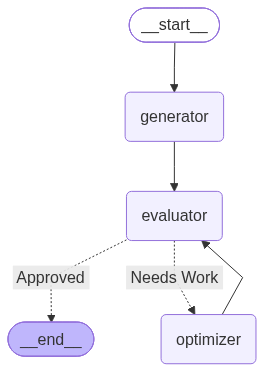

LangGraph concept explainer compiled successfully.


In [13]:
# === Build the Graph ===
workflow = StateGraph(ExplainerState)

# Add nodes
workflow.add_node("generator", generator_node)
workflow.add_node("evaluator", evaluator_node)
workflow.add_node("optimizer", optimizer_node)

# Add edges
workflow.add_edge(START, "generator")
workflow.add_edge("generator", "evaluator")

# Conditional edge: evaluator decides whether to approve or refine
workflow.add_conditional_edges(
    "evaluator",
    route_explanation,
    {
        "Approved": END,
        "Max Reached": END,
        "Needs Work": "optimizer"
    }
)

# Optimizer loops back to evaluator
workflow.add_edge("optimizer", "evaluator")

# Compile
concept_explainer = workflow.compile()

# Display the graph
display(Image(concept_explainer.get_graph().draw_mermaid_png()))
print("LangGraph concept explainer compiled successfully.")

**Understanding the Graph Visualization:**

The diagram shows the evaluator-optimizer loop:

```
START → [Generator] → [Evaluator] ── Pass? ── Yes → END
                            ↑         │
                            │        No
                            │         │
                            │         ↓
                            └── [Optimizer]
```

**The Flow:**
1. `START` → Generator: Create initial explanation (runs once)
2. Generator → Evaluator: Assess the explanation
3. Evaluator → (conditional):
   - If passed: → `END`
   - If failed: → Optimizer
4. Optimizer → Evaluator: Loop back with improved explanation
5. Repeat steps 3 and 4 until passed or max iterations

### Step 4: Test the Concept Explainer

Let's test with the same concepts we used for the OpenAI Agents SDK example.

#### Run the Following Cell

In [14]:
# Test Concept A: Transformers
lg_concept_a = """Transformers work by converting each word into three vectors (queries, keys, and values), 
then comparing every word's query against every other word's key to calculate attention scores 
that determine how much each word should 'focus on' every other word."""

display(Markdown(f"# Test Concept A: Transformers\n\n**Original Concept:**\n\n> {lg_concept_a}"))

result_a = concept_explainer.invoke({
    "concept": lg_concept_a,
    "max_iterations": 3
})

display(Markdown(f"**Final Grade:** {result_a['grade'].upper()}"))
display(Markdown(f"**Iterations Used:** {result_a['iteration']}"))
display(Markdown(f"## Final Explanation\n\n> {result_a['explanation']}"))

# Test Concept A: Transformers

**Original Concept:**

> Transformers work by converting each word into three vectors (queries, keys, and values), 
then comparing every word's query against every other word's key to calculate attention scores 
that determine how much each word should 'focus on' every other word.

**Final Grade:** PASS

**Iterations Used:** 1

## Final Explanation

> Imagine you are in a classroom with your friends. Each friend has a secret note they want to share. Every note has three parts: a question, a lock, and an answer.

When you want to listen, you pick up your question. You walk around the room and try your question with everyone’s lock to see whose lock your question fits best.

If your question fits someone’s lock really well, you pay a lot of attention to their answer. If it doesn't fit, you don’t pay much attention.

This way, every friend looks at everyone else’s notes and listens to the ones that match best. This helps everyone understand what’s most important to talk about.

#### Run the Following Cell

In [15]:
# Test Concept B: Photosynthesis
lg_concept_b = """Photosynthesis is the process by which plants convert light energy into chemical energy 
through absorption of carbon dioxide and water, which are converted into glucose and oxygen 
through chemical reactions in the chloroplasts."""

display(Markdown(f"# Test Concept B: Photosynthesis\n\n**Original Concept:**\n\n> {lg_concept_b}"))

result_b = concept_explainer.invoke({
    "concept": lg_concept_b,
    "max_iterations": 3
})

display(Markdown(f"**Final Grade:** {result_b['grade'].upper()}"))
display(Markdown(f"**Iterations Used:** {result_b['iteration']}"))
display(Markdown(f"## Final Explanation\n\n> {result_b['explanation']}"))

# Test Concept B: Photosynthesis

**Original Concept:**

> Photosynthesis is the process by which plants convert light energy into chemical energy 
through absorption of carbon dioxide and water, which are converted into glucose and oxygen 
through chemical reactions in the chloroplasts.

**Final Grade:** PASS

**Iterations Used:** 1

## Final Explanation

> Plants are like tiny chefs. They use sunlight, water, and air to make their own food. They mix these things in their leaves. This makes sugar for them to eat and air for us to breathe.

## Implement the Product Description Generator Workflow With LangGraph

Now let's implement the **product description generator** using LangGraph's conditional edges.

There are two code cells below:

* In the first code cell, the schema, state, and most node functions have been defined for you.
* In the second code cell, your task is to complete the `route_description()` function that decides whether to approve the description or loop back for improvement.

    **Hint:** Look at the implementation of the `route_explanation()` function in the example above. You need to check the `grade` in the state and return:
    - `"Approved"` if the grade is equal to `"pass"`
    - `"Needs Improvement"` otherwise

#### Run the Following Cell

In [16]:
# === Evaluation Schema ===
class LGDescEvaluation(BaseModel):
    """Evaluation of a product description."""
    grade: Literal["pass", "fail"] = Field(
        description="Whether the description is marketing-ready"
    )
    feedback: str = Field(
        description="Feedback on what to improve"
    )


# === Workflow State ===
class DescriptionState(TypedDict):
    product_details: str    # Input product details
    description: str        # Current description
    grade: str              # "pass" or "fail"
    feedback: str           # Evaluator's feedback
    iteration: int          # Current iteration
    max_iterations: int     # Maximum allowed iterations


# Create evaluator with structured output
desc_evaluator_llm = llm.with_structured_output(LGDescEvaluation)


# === Generator Node ===
def desc_generator_node(state: DescriptionState):
    """Generate initial product description."""
    result = llm.invoke([
        SystemMessage(content="""You are an expert product copywriter. 
        Create a compelling description. Highlight benefits, use persuasive language, 
        be concise but complete. Output ONLY the description, nothing else."""),
        HumanMessage(content=f"Create a product description for:\n\n{state['product_details']}")
    ])
    return {"description": result.content, "iteration": 1}


# === Evaluator Node ===
def desc_evaluator_node(state: DescriptionState):
    """Evaluate if the description is marketing-ready."""
    result = desc_evaluator_llm.invoke([
        SystemMessage(content="""You are a senior marketing director. Evaluate this product description.
Check for: benefit-focus, emotional appeal, clarity, persuasiveness, professional tone.
Be constructive but maintain high standards."""),
        HumanMessage(content=f"Description to evaluate:\n\n{state['description']}")
    ])
    return {"grade": result.grade, "feedback": result.feedback}


# === Optimizer Node ===
def desc_optimizer_node(state: DescriptionState):
    """Improve the description based on feedback."""
    result = llm.invoke([
        SystemMessage(content="""You are an expert at improving product descriptions 
        based on feedback. Keep what works, fix what was flagged. Output ONLY the improved 
        description, nothing else."""),
        HumanMessage(content=f"""Current description:
{state['description']}

Feedback to address:
{state['feedback']}

Create an improved description.""")
    ])
    return {"description": result.content, "iteration": state["iteration"] + 1}


print("All description nodes defined: generator, evaluator, optimizer")

All description nodes defined: generator, evaluator, optimizer


In the code cell below, replace the line `raise NotImplementedError("Your code is missing.")` with your code. As this is an ungraded notebook, your work will not be submitted for grading. 

#### Enter Your Solution Then Run the Following Cell

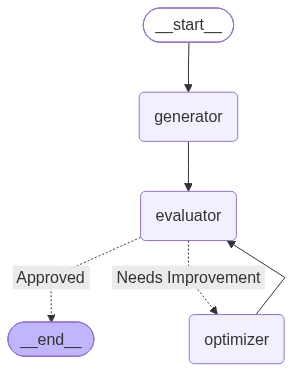

Product description generator compiled successfully.


In [17]:
# === Routing Function ===
def route_description(state: DescriptionState):
    """Decide whether to approve the description or continue refining.
    
    Returns:
        'Approved': Evaluation passed - go to END
        'Needs Improvement': Evaluation failed - go to optimizer
        'Max Reached': Too many iterations - go to END anyway
    
    Hint: Check state['grade'] and state['iteration']
    """
    # Safety check: don't loop forever
    if state["iteration"] >= state["max_iterations"]:
        return "Max Reached"
    
    # =====================================================
    # Check if the grade is "pass"
    # Return "Approved" if passed, "Needs Improvement" if not
    # =====================================================
    
    if state['grade'] == "pass":
        return "Approved"
    else:
        return "Needs Improvement"


# === Build the Graph ===
desc_workflow = StateGraph(DescriptionState)

# Add nodes
desc_workflow.add_node("generator", desc_generator_node)
desc_workflow.add_node("evaluator", desc_evaluator_node)
desc_workflow.add_node("optimizer", desc_optimizer_node)

# Add edges
desc_workflow.add_edge(START, "generator")
desc_workflow.add_edge("generator", "evaluator")

# Conditional edge using your routing function
desc_workflow.add_conditional_edges(
    "evaluator",
    route_description,
    {
        "Approved": END,
        "Max Reached": END,
        "Needs Improvement": "optimizer"
    }
)

# Optimizer loops back to evaluator
desc_workflow.add_edge("optimizer", "evaluator")

# Compile
description_generator = desc_workflow.compile()

display(Image(description_generator.get_graph().draw_mermaid_png()))
print("Product description generator compiled successfully.")

<details>
<summary style="text-align: left; background-color: #e3fbe3; color: #2a8bc6; padding: 10px 10px; cursor: pointer;" role="alert"><strong>✅ Solution</strong></summary>

<p style="padding: 10px;">
Sample Solution:
<pre>
if state["grade"] == "pass":
        return "Approved"
else:
        return "Needs Improvement"    
</pre>
</p>

</details>

### Test Your Product Description Generator Workflow

Run the cells below to test with two different products.

#### Run the Following Cell

In [18]:
# Test Product A: Wireless headphones
lg_product_a = """Wireless noise-canceling headphones with 30-hour battery life, premium leather cushions, 
Bluetooth 5.2 connectivity, and adaptive sound technology."""

display(Markdown(f"# Test Product A: Wireless Headphones\n\n**Product Details:**\n\n> {lg_product_a}"))

lg_result_a = description_generator.invoke({
    "product_details": lg_product_a,
    "max_iterations": 3
})

display(Markdown(f"**Final Grade:** {lg_result_a['grade'].upper()}"))
display(Markdown(f"**Iterations Used:** {lg_result_a['iteration']}"))
display(Markdown(f"## Final Description\n\n> {lg_result_a['description']}"))

# Test Product A: Wireless Headphones

**Product Details:**

> Wireless noise-canceling headphones with 30-hour battery life, premium leather cushions, 
Bluetooth 5.2 connectivity, and adaptive sound technology.

**Final Grade:** PASS

**Iterations Used:** 1

## Final Description

> Immerse yourself in pure audio luxury with our wireless noise-canceling headphones. Featuring adaptive sound technology and advanced Bluetooth 5.2 connectivity, every note, call, and beat comes through in flawless detail—no interruptions, just cinematic clarity. Sink into plush, premium leather cushions that provide ergonomic comfort for hours, making even extended listening a true pleasure. Enjoy up to 30 hours of battery life on a single charge—perfect for work, flights, and everything in between. Effortlessly sleek, endlessly powerful, and designed for those who demand superior sound wherever life takes them.

#### Run the Following Cell

In [19]:
# Test Product B: Ergonomic office chair
lg_product_b = """Ergonomic office chair with adjustable lumbar support, breathable mesh back, 
4D armrests, seat depth adjustment, and 10-year warranty."""

display(Markdown(f"# Test Product B: Ergonomic Office Chair\n\n**Product Details:**\n\n> {lg_product_b}"))

lg_result_b = description_generator.invoke({
    "product_details": lg_product_b,
    "max_iterations": 3
})

display(Markdown(f"**Final Grade:** {lg_result_b['grade'].upper()}"))
display(Markdown(f"**Iterations Used:** {lg_result_b['iteration']}"))
display(Markdown(f"## Final Description\n\n> {lg_result_b['description']}"))

# Test Product B: Ergonomic Office Chair

**Product Details:**

> Ergonomic office chair with adjustable lumbar support, breathable mesh back, 
4D armrests, seat depth adjustment, and 10-year warranty.

**Final Grade:** PASS

**Iterations Used:** 1

## Final Description

> Experience all-day comfort and productivity with our Ergonomic Office Chair. Designed for ultimate support, it features adjustable lumbar support to perfectly align your spine and a breathable mesh back that keeps you cool throughout the workday. Personalize your fit with 4D armrests and seat depth adjustment, ensuring optimal posture no matter your body type. Built with premium materials and backed by a 10-year warranty, this chair is the smart investment for your workspace—where comfort meets long-lasting durability.

---

## Reflection: Evaluator-Optimizer (Plan Reflection)

You've now implemented the **evaluator-optimizer** pattern using two different frameworks. Take a moment to reflect on what you've learned.

### Three Types of Reflection

Reflection in AI agents can take three forms:

| Type | How It Works | Trade-offs |
|------|--------------|------------|
| **Self-Reflection** | Same LLM evaluates its own output | Simplest, fastest; may have bias |
| **Cross-Reflection** | Separate LLM evaluates another's output | Clean context, unbiased; more complexity |
| **Human Reflection** | Human reviews and provides feedback | Highest quality; slowest, not fully automated |

We implemented cross-reflection (evaluator-optimizer), where a separate agent evaluates the output and provides feedback.

### Structured Feedback is Essential

The evaluator must return structured output that your code can process:

```python
class EvaluationResult(BaseModel):
    grade: Literal["pass", "fail"]
    feedback: str
```

Without structured output, you'd have to parse free-form text to determine whether to loop. The grade field makes the decision unambiguous.

### Safeguards Against Infinite Loops

Two critical safeguards:

1. **Maximum iterations**: Always set a limit
   ```python
   max_iterations = 5 # It can be any number, but 5 is a good starting point
   ```

2. **Diminishing returns acceptance**: After several iterations, accept "good enough"

### When Evaluator-Optimizer Adds Value

Use this pattern when:
- Quality varies and needs verification
- There are clear, measurable standards
- Iteration can meaningfully improve results
- The cost of multiple iterations is acceptable

Don't use it when:
- The first response is usually good enough
- Standards are subjective or unclear
- Speed is more important than quality
- The task doesn't benefit from iteration

### Summary of Agentic Patterns

Congratulations! You've now completed the five core agentic patterns:

| Pattern | Key Characteristic | When to Use |
|---------|-------------------|-------------|
| **Prompt Chaining** | Sequential steps, each transforms output | Linear workflows |
| **Routing** | Conditional branching based on input | Different handling per category |
| **Parallelization** | Multiple tasks run concurrently | Independent subtasks, known at design time |
| **Orchestrator** | Dynamic planning, worker delegation | Subtasks determined at runtime |
| **Evaluator-Optimizer** | Feedback loop for quality | Iterative improvement needed |

These patterns can be combined. For example:
- **Orchestrator + Evaluator**: Plan dynamically, then evaluate and refine each worker's output
- **Routing + Parallelization**: Route to different parallel workflows based on input
- **Chaining + Evaluation**: Evaluate at each step before proceeding

Together, these patterns form the foundation for building sophisticated, reliable AI systems, and you have successfully mastered these! Good luck!